## HW #2 - Data Acquisition, Processing, and Communication

For this assignment, reservoir management requests recommendations to balance water storage and mitigate flooding potential for the previous water year on April 1st, 2025, for a reservoir of your choice in the Upper Colorado River Basin, or approved by the instructor. Your sub-basin/reservoir of choice should have at least 1 SNOTEL station, a USGS streamflow gauge near the inlet of the reservoir that is hydrologically relevant to the upstream SNOTEL site(s), and no significant reservoir upstream.

USGS gauge at a reservoir inlet = [10133980](https://waterdata.usgs.gov/monitoring-location/USGS-10133980/#dataTypeId=continuous-00065-0&period=P7D&showFieldMeasurements=true) East Canyon Creek above East Canyon Res near Morgan, UT

### 1. Area of interest

This section includes a map of the USGS gauge and SNOTEL station(s)

In [1]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import warnings
warnings.filterwarnings("ignore")

#### USGS and basin map

In [2]:
nldi = NLDI()
usgs_gage_id = "10133980" 

In [3]:
basinname = 'EastCanyonBasin'

#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

In [20]:
# if needed to trust map below
!jupyter trust *.ipynb

Signing notebook: res_mgmt.ipynb


In [5]:
# create map of USGS gauge and basin
m = mapping.basin_mapping(basin, site_feature)
m

In [17]:
# save png of basin map with topo basemap
os.makedirs("images", exist_ok=True)
basin_web = basin.to_crs(epsg=3857)
site_web = site_feature.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))
basin_web.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1, alpha=0.55)
site_web.plot(ax=ax, color="blue", markersize=45)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)
ax.set_axis_off()
fig.savefig("./images/east_canyon_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)

#### SNOTEL sites within basin

In [4]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,684_UT_SNTL,Parleys Summit,SNOTEL,2311.907959,40.761841,-111.629173,Utah,160201020103,12TVL,Western Rocky Mountains,1978-10-01,2026-03-24,True,POINT (-111.62917 40.76184)
1,814_UT_SNTL,Thaynes Canyon,SNOTEL,2813.303955,40.623501,-111.533218,Utah,160201020101,12TVK,Western Rocky Mountains,1988-06-20,2026-03-24,True,POINT (-111.53322 40.6235)


In [7]:
# add snotel sites to map
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

In [5]:
# save png of basin map with topo basemap and labeled SNOTEL sites
os.makedirs("images", exist_ok=True)
basin_web = basin.to_crs(epsg=3857)
site_web = site_feature.to_crs(epsg=3857)
snotel_web = gdf_in_bbox.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))
basin_web.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1, alpha=0.55)
snotel_web.plot(ax=ax, color="purple", markersize=45, marker="^", edgecolor="black", linewidth=0.4)
site_web.plot(ax=ax, color="blue", markersize=45)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

for _, row in snotel_web.iterrows():
    label = str(row.get("name", row.get("code", "SNOTEL")))
    ax.annotate(
        label,
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        color="black",
        bbox={"facecolor": "white", "alpha": 0.7, "pad": 1, "edgecolor": "none"},
    )

gage_x = site_web.geometry.iloc[0].x
gage_y = site_web.geometry.iloc[0].y
ax.annotate(
    f"USGS {usgs_gage_id}",
    (gage_x, gage_y),
    xytext=(6, -10),
    textcoords="offset points",
    fontsize=7,
    color="navy",
    bbox={"facecolor": "white", "alpha": 0.8, "pad": 1, "edgecolor": "none"},
 )

ax.set_axis_off()
fig.savefig("./images/east_canyon_map_snotel.png", dpi=300, bbox_inches="tight")
plt.close(fig)

### 2. SWE analysis for SNOTEL sites

Create figures or tables that communicate the historical range of SWE, similar to a SNOTEL site figure

In [5]:
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,684_UT_SNTL,Parleys Summit,SNOTEL,2311.907959,40.761841,-111.629173,Utah,160201020103,12TVL,Western Rocky Mountains,1978-10-01,2026-03-24,True,POINT (-111.62917 40.76184)
1,814_UT_SNTL,Thaynes Canyon,SNOTEL,2813.303955,40.623501,-111.533218,Utah,160201020101,12TVK,Western Rocky Mountains,1988-06-20,2026-03-24,True,POINT (-111.53322 40.6235)


In [6]:
# retrieve snotel data
# Use the getData module to retrieve data 
OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

for i in gdf_in_bbox.index:
    getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.state[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)


Start retrieving data for Parleys Summit, 684_UT_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/684:Ut:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-24/WTEQ::value?fitToScreen=false
Start retrieving data for Thaynes Canyon, 814_UT_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/814:Ut:SNTL%7Cid=%22%22%7Cname/1988-06-20,2026-03-24/WTEQ::value?fitToScreen=false


In [12]:
# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'Utah'
sitedict = dict()
WY = 2025

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

sitedict['684_UT_SNTL'].head()

#rename dict keys to be more useful
sitedict['PARLEYS'] = sitedict.pop('684_UT_SNTL')
sitedict['THAYNES'] = sitedict.pop('814_UT_SNTL')

sitedict['THAYNES'].head()


684_UT_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
814_UT_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


,M,D,1988_SWE_in,1989_SWE_in,1990_SWE_in,1991_SWE_in,1992_SWE_in,1993_SWE_in,1994_SWE_in,1995_SWE_in,...,2026_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.018421,0.0,0.0,0.00,0.600000,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.034211,0.0,0.0,0.00,1.100001,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.050000,0.0,0.0,0.00,1.100001,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.700000,...,0.0,0.0,0.0,0.0,0.092105,0.0,0.0,0.40,0.900000,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.200001,...,0.0,0.0,0.0,0.0,0.123684,0.0,0.0,0.53,1.200001,2023-10-05


In [10]:
# Check data availability for THAYNES
print(f'THAYNES shape: {sitedict["THAYNES"].shape}')
print(f'First date: {sitedict["THAYNES"].index[0]}')
print(f'Last date: {sitedict["THAYNES"].index[-1]}')
print(f'Does "04-01" exist? {"04-01" in sitedict["THAYNES"].index}')

print('\nPARLEYS:')
print(f'First date: {sitedict["PARLEYS"].index[0]}')
print(f'Last date: {sitedict["PARLEYS"].index[-1]}')
print(f'Does "04-01" exist? {"04-01" in sitedict["PARLEYS"].index}')

THAYNES shape: (103, 50)
First date: 10-01
Last date: 01-11
Does "04-01" exist? False

PARLEYS:
First date: 10-01
Last date: 07-31
Does "04-01" exist? True


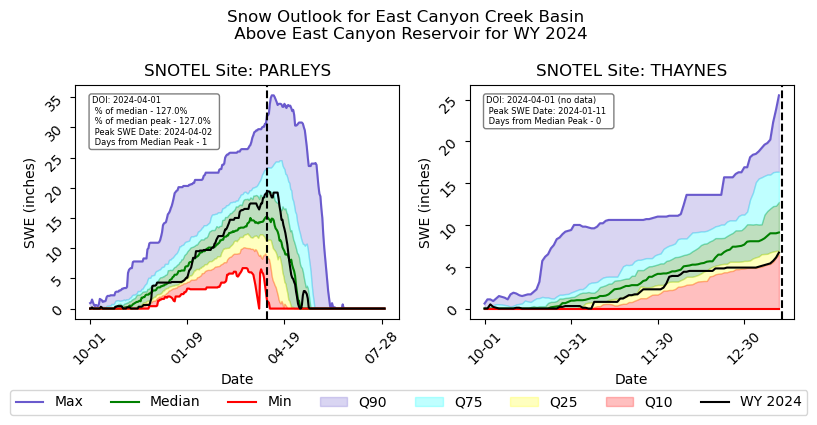

In [11]:
watershed = "East Canyon Creek"
AOI = 'Above East Canyon Reservoir'
DOI = '04-01' #must be in MM-DD form
WY = 2024

SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)

In [ ]:
# Thaynes isn't showing past January even though the files/snotel/df has data.